In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def get_angle(v1, v2, v3):
    dot = np.dot(v1-v2, v1-v3)
    cross = ((v1-v2)[0])*((v1-v3)[1]) - ((v1-v2)[1])*((v1-v3)[0])
    return np.arctan2(cross, dot)

In [8]:
def get_grads(j, dist, angle, h=1e-4): #Gets del(Ej)/del(xk) over k
    v = np.zeros((6, 2))
    grad = np.zeros((6, 2))
    v[0] = np.zeros(2)
    v[1] = np.array([dist[0]*np.cos(angle[0]), dist[0]*np.sin(angle[0])])
    v[2] = np.array([dist[1]*np.cos(angle[1]), dist[1]*np.sin(angle[1])])
    v[3] = np.array([dist[2]*np.cos(angle[2]), dist[2]*np.sin(angle[2])])
    v[4] = np.array([dist[3]*np.cos(angle[3]), dist[3]*np.sin(angle[3])])
    v[5] = np.array([dist[4]*np.cos(angle[4]), dist[4]*np.sin(angle[4])])
    for i in range(1, 6):
        v[i, 0] = v[i, 0] + h
        Epx = get_energy(v, thetareq[j])
        v[i, 0] = v[i, 0] - 2*h
        Emx = get_energy(v, thetareq[j])
        v[i, 0] = v[i, 0] + h
        v[i, 1] = v[i, 1] + h
        Epy = get_energy(v, thetareq[j])
        v[i, 1] = v[i, 1] - 2*h
        Emy = get_energy(v, thetareq[j])
        v[i, 1] = v[i, 1] + h
        
        grad[i, :] = np.array([(Epx-Emx)/(2*h), (Epy-Emy)/(2*h)]) #del(Ej)/del(vi) = del(Ej)/del(xi)
        
    grad[0, :] = -(grad[1, :] + grad[2, :] + grad[3, :] + grad[4, :] + grad[5, :]) #del(Ej)/del(xj) = -sum(del(Ej)/del(vk))
    return grad

In [9]:
def get_energy(vec, reqd_angles):
    angle1 = get_angle(vec[0], vec[1], vec[2])
    angle2 = get_angle(vec[0], vec[1], vec[3])
    angle3 = get_angle(vec[0], vec[1], vec[4])
    angle4 = get_angle(vec[0], vec[1], vec[5])
    E = 4 - np.cos(angle1 - reqd_angles[0]) - np.cos(angle2 - reqd_angles[1]) - np.cos(angle3 - reqd_angles[2]) - np.cos(angle4 - reqd_angles[3])
    return E

In [118]:
def evolve(positions, thetareq, alpha = 1e-3):
    E = 0
    grads = np.zeros(np.shape(positions))
    for i in range(6): #Decides which bot is in the active phase currently
        v1 = positions[i]
        v2 = positions[(i+1)%6]
        v3 = positions[(i+2)%6]
        v4 = positions[(i+3)%6]
        v5 = positions[(i+4)%6]
        v6 = positions[(i+5)%6]
        ref = np.array([1, 0])
        dist = np.array([np.linalg.norm(v1-v2), np.linalg.norm(v1-v3), np.linalg.norm(v1-v4), np.linalg.norm(v1-v5), np.linalg.norm(v1-v6)]) #Gets perfect distance data. The bot does this using distance data frm intensity values
        angle = np.array([get_angle(v1, v1+ref, v2), get_angle(v1, v1+ref, v3), get_angle(v1, v1+ref, v4), get_angle(v1, v1+ref, v5), get_angle(v1, v1+ref, v6)]) #Gets perfect angle data. The bot does this using bearing data from IR detectors
        diff = np.roll(get_grads(i, dist, angle), i , axis=0) #Gets grads corresponding to Ei, rolls the matrix to ensure bot-wise gradient ordering
        grads = grads + diff
        E2 = get_energy(np.array([v1, v2, v3, v4, v5, v6]), thetareq[i]) #Gets energy of the current configuration wrt bot i
        #E.append(diff)
        E = E + E2
    new_positions = positions - alpha*grads
    return new_positions, E, grads

In [34]:
def total_energy(positions, thetareqd):
    E = 0
    for i in range(6):
        E = E + get_energy(np.roll(positions, -i, axis = 0), thetareqd[i])
    return E

Firstly, lets try to form a hexagon

In [44]:
thetareq1 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq2 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq3 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq4 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq5 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq6 = np.array([30, 60, 90, 120])*(np.pi/180)
thetareq = np.array([thetareq1, thetareq2, thetareq3, thetareq4, thetareq5, thetareq6])
positions = np.random.randn(6, 2) * 2

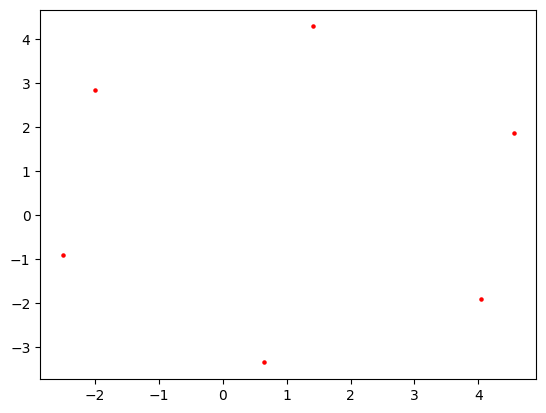

In [116]:
E = 30
while E > 0.002:
    positions, E, grads = evolve(positions, thetareq)
    if step%10 ==0:
        print(E)
plt.scatter(positions[:, 0], positions[:, 1], color = 'red', s = 5)
plt.show()

In [117]:
print(np.linalg.norm(positions[0] - positions[1]))
print(np.linalg.norm(positions[1] - positions[2]))
print(np.linalg.norm(positions[2] - positions[3]))
print(np.linalg.norm(positions[3] - positions[4]))
print(np.linalg.norm(positions[4] - positions[5]))
print(np.linalg.norm(positions[5] - positions[0]))

3.699071333768796
3.7869382804421274
3.9719125539028823
3.6996417200449545
3.7706851501423535
3.9858097529114507


Stuff required to be added:
1. Accounting for measurement noise and errors
2. Realistic step sizes based on limitations on Vibration motors
3. Other shapes